In [173]:
import sys
print(sys.path)

['/usr/lib/python314.zip', '/usr/lib/python3.14', '/usr/lib/python3.14/lib-dynload', '', '/home/swaraj/python/Plasma/ss/lib/python3.14/site-packages', '/home/swaraj/Git/Plasma/DTT', '/home/swaraj/Git/Plasma/DTT', '/home/swaraj/Git/Plasma/DTT', '/home/swaraj/Git/Plasma/DTT', '/home/swaraj/Git/Plasma/DTT', '/home/swaraj/Git/Plasma/DTT', '/home/swaraj/Git/Plasma/DTT', '/home/swaraj/Git/Plasma/DTT', '/home/swaraj/Git/Plasma/DTT', '/home/swaraj/Git/Plasma/DTT']


In [174]:
import os
sys.path.append(os.path.abspath(".."))

In [175]:
import importlib
from DTTP_resources import psiBfield

importlib.reload(psiBfield)

g = psiBfield.extract_g()
psi_norm, BR, Bphi, BZ = psiBfield.compute_B(g)

g_file keywords extracted
Psi Normalized and Magnetic field BR Bphi BZ computed.


In [176]:
import matplotlib.pyplot as plt
import numpy as np

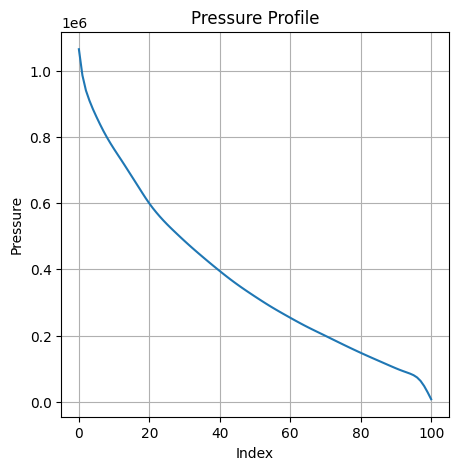

In [177]:
plt.figure(figsize=(5, 5))
plt.plot(g.pres)
plt.xlabel('Index')
plt.ylabel('Pressure')
plt.title('Pressure Profile')
plt.grid()
plt.show()

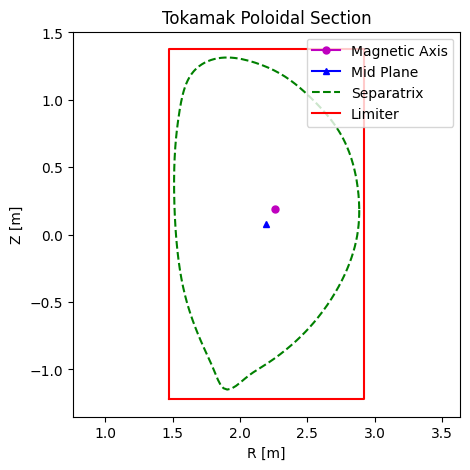

In [178]:
plt.figure(figsize=(5,5))
plt.plot(g.rmaxis, g.zmaxis, 'm', marker = 'o', markersize = 5, label = "Magnetic Axis")
plt.plot(g.rcentr, g.zmid, 'b',marker = '^', markersize = 5, label = "Mid Plane")
plt.plot(g.rbdry, g.zbdry, 'g--', label = "Separatrix")
plt.plot(g.rlim, g.zlim, 'r', label = "Limiter")
plt.title("Tokamak Poloidal Section")
plt.xlim(g.r_grid[:,0][0], g.r_grid[:,0][-1])
plt.ylim(g.z_grid[0,:][0], g.z_grid[0,:][-1])
plt.xlabel("R [m]")
plt.ylabel("Z [m]")
plt.axis('equal')
plt.legend(loc='upper right')
plt.show()

/tmp/ipykernel_90204/1801196969.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


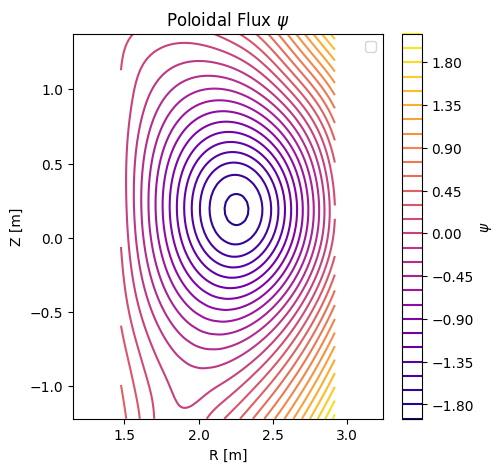

In [179]:
plt.figure(figsize = (5,5))

plt.contour(g.r_grid, g.z_grid, g.psi, levels = 30, cmap = 'plasma')
plt.colorbar(label = r'$\psi$')
plt.xlabel("R [m]")
plt.ylabel("Z [m]")
plt.title(r"Poloidal Flux $\psi$")
plt.axis('equal')
plt.legend()
plt.show()

/tmp/ipykernel_90204/1103649705.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


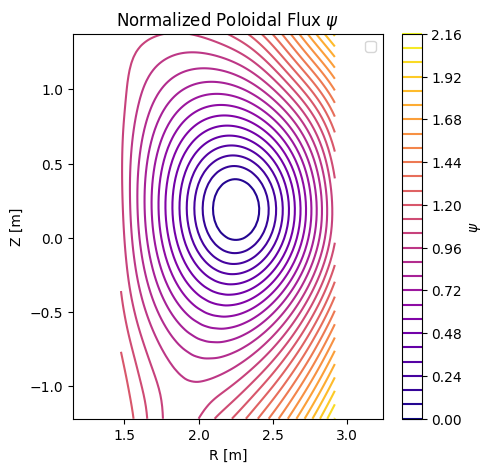

In [180]:
plt.figure(figsize = (5,5))

plt.contour(g.r_grid, g.z_grid, psi_norm, levels = 30, cmap = 'plasma')
plt.colorbar(label = r'$\psi$')
plt.xlabel("R [m]")
plt.ylabel("Z [m]")
plt.title(r"Normalized Poloidal Flux $\psi$")
plt.axis('equal')
plt.legend()
plt.show()

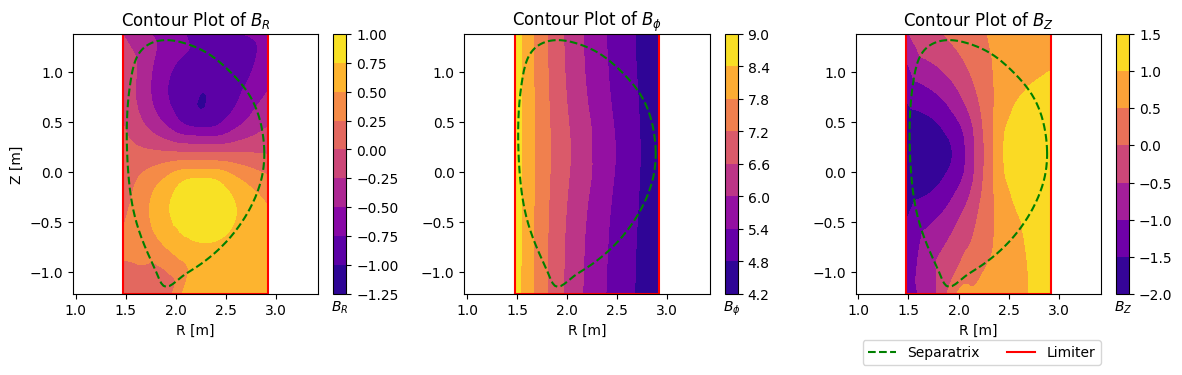

In [181]:
plt.figure(figsize = (12,4))

plt.subplot(1,3,1)
plt.contourf(g.r_grid, g.z_grid, BR, cmap = 'plasma')
cbar = plt.colorbar()
cbar.ax.set_xlabel(r'$B_R$')
cbar.ax.xaxis.set_label_position('bottom')
plt.xlabel('R [m]')
plt.ylabel('Z [m]')
plt.axis('equal')
plt.plot(g.rbdry, g.zbdry, 'g--', label = 'Separatrix')
plt.plot(g.rlim, g.zlim, 'r', label = 'Limiter')
plt.title(r'Contour Plot of $B_R$')

plt.subplot(1,3,2)
plt.contourf(g.r_grid, g.z_grid, Bphi, cmap = 'plasma')
cbar = plt.colorbar()
cbar.ax.set_xlabel(r'$B_\phi$')
cbar.ax.xaxis.set_label_position('bottom')
plt.xlabel('R [m]')
# plt.ylabel('Z [m]')
plt.axis('equal')
plt.plot(g.rbdry, g.zbdry, 'g--', label = 'Separatrix')
plt.plot(g.rlim, g.zlim, 'r', label = 'Limiter')
plt.title(r'Contour Plot of $B_{\phi}$')

plt.subplot(1,3,3)
plt.contourf(g.r_grid, g.z_grid, BZ, cmap = 'plasma')
cbar = plt.colorbar()
cbar.ax.set_xlabel(r'$B_Z$')
cbar.ax.xaxis.set_label_position('bottom')
plt.xlabel('R [m]')
# plt.ylabel('Z [m]')
plt.axis('equal')
plt.plot(g.rbdry, g.zbdry, 'g--', label = 'Separatrix')
plt.plot(g.rlim, g.zlim, 'r', label = 'Limiter')
plt.legend(loc='lower left', ncols=2, bbox_to_anchor=(0,-0.3))
plt.title(r'Contour Plot of $B_Z$')

plt.tight_layout()
plt.show()


In [182]:
rtraj, ztraj = psiBfield.field_tracing(g, psi_norm, BR, BZ)

Poloidal field line trajectories computed.


In [183]:
cumulative_distances = []
for i in range(len(rtraj)):
    dr = np.diff(rtraj[i])
    dz = np.diff(ztraj[i])
    distances = np.sqrt(dr**2 + dz**2)
    cumulative_distance = np.cumsum(distances)
    cumulative_distance = np.insert(cumulative_distance, 0, 0)
    cumulative_distances.append([cumulative_distance])


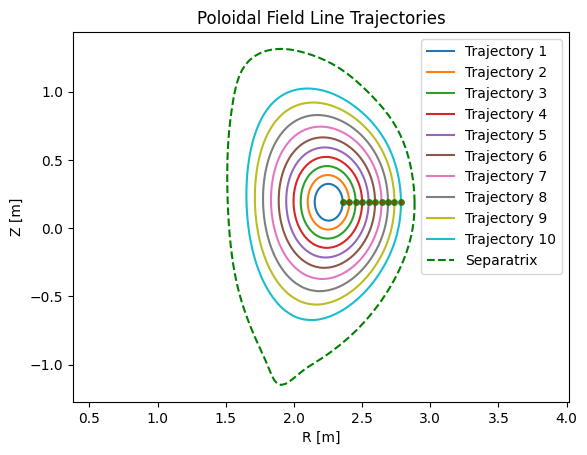

In [184]:
for i in range(len(rtraj)):
    plt.plot(rtraj[i], ztraj[i], label = f"Trajectory {i+1}")
    plt.plot(rtraj[i][0], ztraj[i][0], 'go', markersize=4, alpha=0.8)
    plt.plot(rtraj[i][-1], ztraj[i][-1], 'ro', markersize=2, alpha=0.4)
plt.plot(g.rbdry, g.zbdry, 'g--', label = "Separatrix")
plt.title("Poloidal Field Line Trajectories")
plt.xlabel("R [m]")
plt.ylabel("Z [m]")
plt.axis('equal')
plt.legend(loc='upper right')
plt.show()

In [185]:
r_grid_points, z_grid_points = psiBfield.grid_points(rtraj, ztraj)

Cumulative distances along trajectories computed.
Grid points along trajectories computed.


In [186]:
r_grid_points

[array([2.35800727, 2.33794788, 2.27554807, 2.19814883, 2.15769848,
        2.15715891, 2.19760563, 2.27547951, 2.33763453, 2.35802587]),
 array([2.40544125, 2.39127616, 2.34714641, 2.27396615, 2.19157322,
        2.13327684, 2.10533344, 2.10451625, 2.13148941, 2.19031023,
        2.27303737, 2.34614912, 2.39072739, 2.4054379 ]),
 array([2.45287522, 2.44183711, 2.40768779, 2.35003835, 2.2713651 ,
        2.18636526, 2.11805618, 2.07432679, 2.05298957, 2.05205974,
        2.07199783, 2.11560919, 2.18495812, 2.27025768, 2.34882416,
        2.40686127, 2.44146073, 2.45287707]),
 array([2.5003092 , 2.49203266, 2.46649514, 2.42357914, 2.36336995,
        2.28771155, 2.20445164, 2.12830083, 2.06958526, 2.02943934,
        2.00591607, 1.99747954, 2.00378104, 2.0257475 , 2.06546339,
        2.12497021, 2.20199652, 2.28529717, 2.36110541, 2.42196997,
        2.46555593, 2.49159862, 2.5002793 ]),
 array([2.54774318, 2.54055048, 2.5183844 , 2.48126602, 2.42927169,
        2.36281344, 2.28384209, 

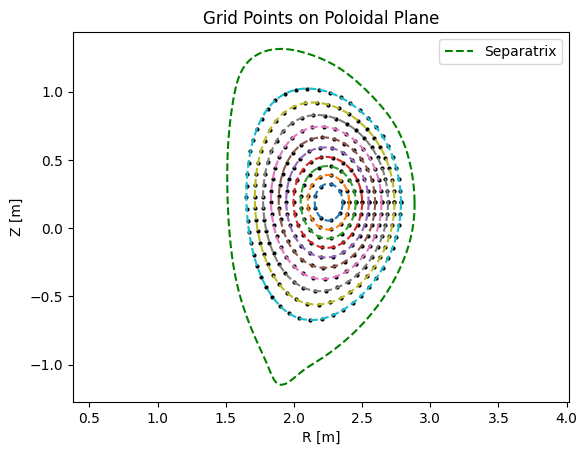

In [188]:
for i in range(len(r_grid_points)):
    plt.plot(r_grid_points[i], z_grid_points[i], 'ko', markersize=2)
    plt.plot(rtraj[i], ztraj[i], '--')
plt.plot(g.rbdry, g.zbdry, 'g--', label = "Separatrix")
plt.title("Grid Points on Poloidal Plane")
plt.xlabel("R [m]")
plt.ylabel("Z [m]")
plt.axis('equal')
plt.legend(loc='upper right')
plt.show()